# Sesión 4 — Matriz de rigidez no lineal y algoritmos de solución

## Aplicación portable: edificio didáctico de 2 pisos

Esta sesión consume el contrato 3.5 de la sesión 3. Relaciona la rigidez seccional $EI_{sec}(P)$ con la matriz del elemento de pórtico 2D y compara control por carga, control por desplazamiento y longitud de arco.

> El solver estructural de la sesión 6 usa control directo de desplazamiento. El ejemplo de longitud de arco de esta sesión es un benchmark pedagógico de un grado de libertad.

## 1. Entorno y trazabilidad

Las importaciones se realizan directamente desde `PUSHOVER_PORTABLE`; no se usan copias de los módulos de la raíz.

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

def buscar_raiz(inicio=None):
    inicio = Path.cwd() if inicio is None else Path(inicio)
    for carpeta in (inicio, *inicio.parents):
        if (carpeta/"temario.md").is_file() and (carpeta/"PUSHOVER_PORTABLE").is_dir():
            return carpeta
    raise FileNotFoundError("No se encontró la raíz del curso.")

RAIZ = buscar_raiz()
PORTABLE = RAIZ/"PUSHOVER_PORTABLE"
if str(PORTABLE) in sys.path:
    sys.path.remove(str(PORTABLE))
sys.path.insert(0, str(PORTABLE))
RUTA_MAESTRA = PORTABLE/"casos"/"edificio_2pisos.json"
RUTA_C03 = RAIZ/"sesion_03"/"resultados_portable_2pisos"/"contrato_sesion03_2pisos.json"

from ejecutar_pushover import cargar_entrada_maestra
from sesion_03.biblioteca_rotulas import leer_contrato_sesion03
from sesion_04 import rigidez_portico
from sesion_04.rigidez_portico import (
    matriz_rigidez_local_portico2d, matriz_transformacion_portico2d,
    rigidez_elemento_portico2d,
)
from sesion_04.solvers_no_lineales import (
    fuerza_normalizada, newton_control_carga, control_desplazamiento,
    longitud_arco_1gdl, extraer_historia,
)
from sesion_06.rotulas_axiales import interpolar_ley_axial

entrada, _, _ = cargar_entrada_maestra(RUTA_MAESTRA)
c03 = leer_contrato_sesion03(RUTA_C03)
biblioteca = c03["biblioteca_rotulas"]
print("Módulo:", Path(rigidez_portico.__file__).relative_to(RAIZ))
print("Contrato S3:", RUTA_C03.relative_to(RAIZ), "schema", c03["schema_version"])
assert PORTABLE in Path(rigidez_portico.__file__).resolve().parents

Módulo: PUSHOVER_PORTABLE\sesion_04\rigidez_portico.py
Contrato S3: sesion_03\resultados_portable_2pisos\contrato_sesion03_2pisos.json schema 3.5


## 2. Matriz local de un elemento 2D

Para los GDL locales $[u_i,v_i,\theta_i,u_j,v_j,\theta_j]^T$, los términos característicos son $EA/L$, $12EI/L^3$, $6EI/L^2$, $4EI/L$ y $2EI/L$. Antes de aplicar apoyos, la matriz debe ser simétrica, semidefinida positiva y contener tres modos de cuerpo rígido.

In [2]:
sid = "C1"
P0 = float(entrada["modelo"]["P_referencia_inicial_kgf"])
sel = interpolar_ley_axial(biblioteca[sid]["positivo"], P0, fuera_de_rango="limitar")
sec = entrada["secciones"][sid]
Ec = entrada["modelo"]["Ec_coef_sqrt_fc"]*np.sqrt(sec["fc_kgf_cm2"])
EA = Ec*sec["b_cm"]*sec["h_cm"]
EI = float(sel["EI_sec_kgf_cm2"])
L = float(entrada["edificio"]["altura_entrepiso_cm"])
k_local = matriz_rigidez_local_portico2d(EA, EI, L)
eig = np.linalg.eigvalsh(k_local)
print(f"EA={EA:.4e} kgf; EI={EI:.4e} kgf·cm²; L={L:.1f} cm")
print(k_local)
print("Autovalores:", eig)
assert np.allclose(k_local, k_local.T)
assert np.count_nonzero(np.abs(eig) < 1e-5*eig.max()) == 3

EA=7.8253e+08 kgf; EI=5.1320e+10 kgf·cm²; L=300.0 cm
[[ 2.6084e+06  0.0000e+00  0.0000e+00 -2.6084e+06  0.0000e+00  0.0000e+00]
 [ 0.0000e+00  2.2809e+04  3.4214e+06  0.0000e+00 -2.2809e+04  3.4214e+06]
 [ 0.0000e+00  3.4214e+06  6.8427e+08  0.0000e+00 -3.4214e+06  3.4214e+08]
 [-2.6084e+06  0.0000e+00  0.0000e+00  2.6084e+06  0.0000e+00  0.0000e+00]
 [ 0.0000e+00 -2.2809e+04 -3.4214e+06  0.0000e+00  2.2809e+04 -3.4214e+06]
 [ 0.0000e+00  3.4214e+06  3.4214e+08  0.0000e+00 -3.4214e+06  6.8427e+08]]
Autovalores: [0.0000e+00 1.7148e-11 1.0811e-07 5.2169e+06 3.4214e+08 1.0265e+09]


## 3. Transformación y tangente degradada

En coordenadas globales, $K_g=T^TK_lT$. El factor $\eta$ permite estudiar una reducción de $EI$; en el pushover real la pérdida tangente resulta de activar y condensar las rótulas, no de asignar arbitrariamente $\eta$.

In [3]:
angulo = np.deg2rad(30)
T = matriz_transformacion_portico2d(angulo)
normas = {}
for eta in (1.0, 0.5, 0.2):
    res = rigidez_elemento_portico2d(EA, EI, L, angulo_rad=angulo, eta=eta)
    normas[eta] = np.linalg.norm(res["global"], 2)
    print(f"η={eta:.1f}: EI_t={res['EI_t']:.4e}; matriz simétrica={np.allclose(res['global'],res['global'].T)}")
assert np.allclose(T@T.T, np.eye(6))
assert normas[0.2] <= normas[0.5] <= normas[1.0]

η=1.0: EI_t=5.1320e+10; matriz simétrica=True
η=0.5: EI_t=2.5660e+10; matriz simétrica=True
η=0.2: EI_t=1.0264e+10; matriz simétrica=True


## 4. Newton–Raphson y estrategia de control

El equilibrio es $r(x,\lambda)=f_{int}(x)-\lambda=0$. Con control por carga se prescribe $\lambda$; cerca de una tangente nula el método pierde capacidad de seguimiento. El control por desplazamiento prescribe $x$, mientras longitud de arco agrega una restricción geométrica.

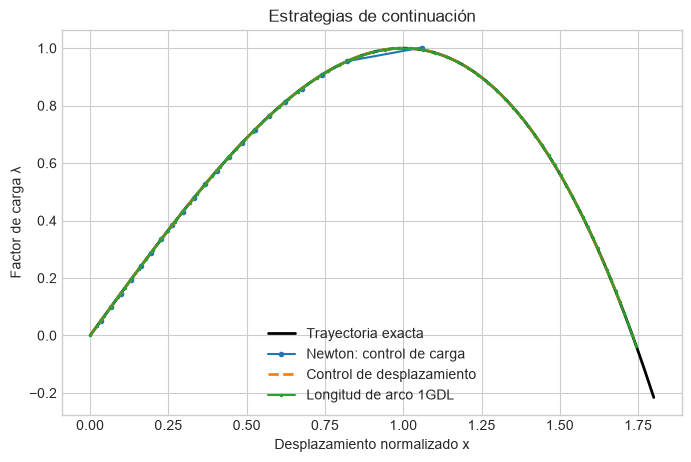

Último paso de control por carga: {'paso': 21, 'lambda': 1.0023809523809524, 'x': 1.060091322163368, 'iteraciones': 25, 'residuo': -0.028465329795597016, 'convergio': False}


In [4]:
h_carga = newton_control_carga(np.linspace(0.05,1.05,22))
h_despl = control_desplazamiento(np.linspace(0,1.7,70))
h_arco = longitud_arco_1gdl(n_pasos=70, ds=0.04)
xc,lc=extraer_historia(h_carga); xd,ld=extraer_historia(h_despl); xa,la=extraer_historia(h_arco)
xx=np.linspace(0,1.8,300)
fig,ax=plt.subplots(figsize=(8,5))
ax.plot(xx,fuerza_normalizada(xx),color="black",lw=2,label="Trayectoria exacta")
ax.plot(xc,lc,"o-",ms=3,label="Newton: control de carga")
ax.plot(xd,ld,"--",lw=2,label="Control de desplazamiento")
ax.plot(xa,la,".-",ms=3,label="Longitud de arco 1GDL")
ax.set(xlabel="Desplazamiento normalizado x",ylabel="Factor de carga λ",title="Estrategias de continuación")
ax.legend(); plt.show()
print("Último paso de control por carga:", h_carga[-1])

## 5. Contrato de la sesión 4

Se verifican todas las secciones con el mismo esquema 2.3 producido por el ejecutor integrado.

In [5]:
verificaciones={}
for sid,sec in entrada["secciones"].items():
    sel=interpolar_ley_axial(biblioteca[sid]["positivo"],P0,fuera_de_rango="limitar")
    EI_i=float(sel["EI_sec_kgf_cm2"])
    Ec_i=entrada["modelo"]["Ec_coef_sqrt_fc"]*np.sqrt(sec["fc_kgf_cm2"])
    EA_i=Ec_i*sec["b_cm"]*sec["h_cm"]
    k=matriz_rigidez_local_portico2d(EA_i,EI_i,L); positivos=np.linalg.eigvalsh(k); positivos=positivos[positivos>1e-6]
    verificaciones[sid]={"P_referencia_kgf":P0,"EA_kgf":float(EA_i),"EI_kgf_cm2":EI_i,
        "L_referencia_cm":L,"matriz_simetrica":bool(np.allclose(k,k.T)),
        "autovalor_minimo_no_nulo":float(positivos.min())}
    assert verificaciones[sid]["matriz_simetrica"] and positivos.min()>0
contrato_s4={"schema_version":"2.3","sesion_origen":"sesion_04","caso_id":entrada["caso_id"],"verificaciones":verificaciones}
salida=RAIZ/"sesion_04"/"resultados_portable_2pisos"; salida.mkdir(parents=True,exist_ok=True)
ruta_c04=salida/"contrato_sesion04_2pisos.json"
ruta_c04.write_text(json.dumps(contrato_s4,ensure_ascii=False,indent=2),encoding="utf-8")
print("Guardado:",ruta_c04.relative_to(RAIZ))
for sid,v in verificaciones.items(): print(sid,f"EI={v['EI_kgf_cm2']:.4e}","simétrica=",v["matriz_simetrica"])

Guardado: sesion_04\resultados_portable_2pisos\contrato_sesion04_2pisos.json
C1 EI=5.1320e+10 simétrica= True
C2 EI=4.4345e+10 simétrica= True
V1 EI=2.8268e+10 simétrica= True
V2 EI=7.7648e+09 simétrica= True


## 6. Cierre

La sesión 3 aporta la rigidez y resistencia seccional; la sesión 4 demuestra cómo ingresan en la matriz y cómo se resuelve equilibrio no lineal. La sesión 5 ensamblará el edificio completo con brazos rígidos, diafragmas y rótulas.